# Task 1


X: (4601, 57) y: (4601,) spam rate: 0.39404477287546186
n_train=230, n_test=4371
epoch    1/120 | loss=0.4378 | acc=0.9391 | ||w||=0.47
epoch   13/120 | loss=0.1923 | acc=0.9435 | ||w||=1.76
epoch   25/120 | loss=0.1525 | acc=0.9609 | ||w||=2.33
epoch   37/120 | loss=0.1322 | acc=0.9696 | ||w||=2.74
epoch   49/120 | loss=0.1196 | acc=0.9739 | ||w||=3.07
epoch   61/120 | loss=0.1103 | acc=0.9739 | ||w||=3.35
epoch   73/120 | loss=0.1031 | acc=0.9783 | ||w||=3.60
epoch   85/120 | loss=0.0974 | acc=0.9783 | ||w||=3.82
epoch   97/120 | loss=0.0927 | acc=0.9783 | ||w||=4.01
epoch  109/120 | loss=0.0888 | acc=0.9783 | ||w||=4.20
epoch  120/120 | loss=0.0855 | acc=0.9783 | ||w||=4.36
epoch    1/120 | loss=0.5523 | acc=0.9435 | ||w||=0.30
epoch   13/120 | loss=0.5214 | acc=0.8652 | ||w||=0.42
epoch   25/120 | loss=0.5202 | acc=0.8609 | ||w||=0.39
epoch   37/120 | loss=0.5270 | acc=0.8565 | ||w||=0.45
epoch   49/120 | loss=0.5201 | acc=0.8391 | ||w||=0.41
epoch   61/120 | loss=0.5210 | acc=0.84

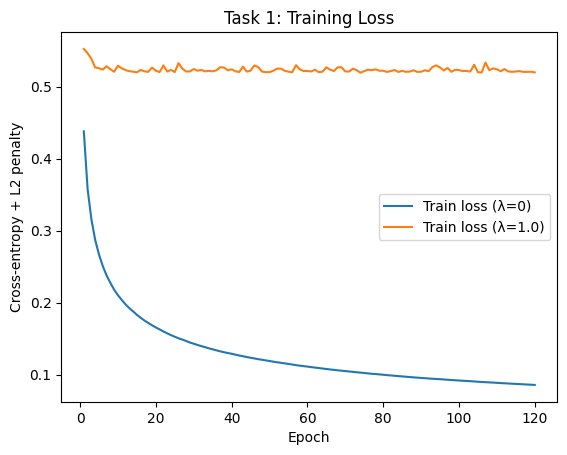

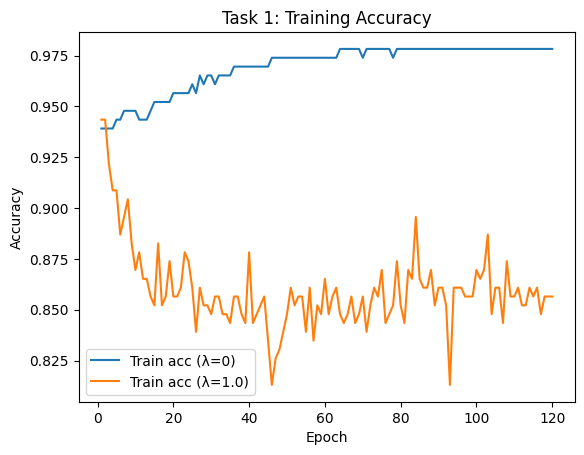

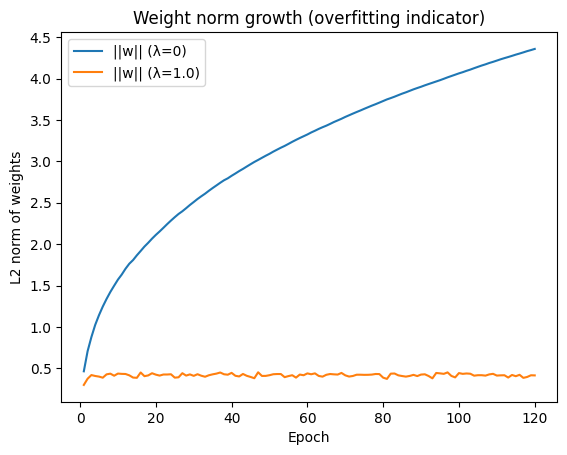

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

DATA_PATH = r"D:\File\Study\Winter 2026\COMP 551\COMP-551\A2\spambase.data"   # <-- change this

BATCH_SIZE = 32
LR = 0.1
EPOCHS = 120
L2_LAMBDA = 1.0   # starting value

def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(p, y):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def accuracy(p, y, thr=0.5):
    return np.mean((p >= thr).astype(int) == y)


# Load data
df = pd.read_csv(DATA_PATH, header=None)
assert df.shape[1] == 58, "Expected 57 features + 1 label = 58 columns"
X = df.iloc[:, :-1].to_numpy(dtype=np.float64)
y = df.iloc[:, -1].to_numpy(dtype=np.int64)

N, d = X.shape
print("X:", X.shape, "y:", y.shape, "spam rate:", y.mean())

# Split
perm = rng.permutation(N)
n_train = int(np.floor(0.05 * N))
train_idx = perm[:n_train]
test_idx  = perm[n_train:]

X_train_raw, y_train = X[train_idx], y[train_idx]
X_test_raw,  y_test  = X[test_idx],  y[test_idx]

print(f"n_train={len(train_idx)}, n_test={len(test_idx)}")


# Standardize
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma[sigma == 0] = 1.0

X_train = (X_train_raw - mu) / sigma
X_test  = (X_test_raw  - mu) / sigma


# Train
def train_logreg_sgd(X, y, lr, epochs, batch_size, l2_lambda, rng):
    n, d = X.shape
    w = rng.normal(0.0, 0.01, size=d)
    b = 0.0

    hist_loss = []
    hist_acc = []
    hist_w_norm = []

    for ep in range(epochs):
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb = Xs[start:end]
            yb = ys[start:end]
            m = Xb.shape[0]

            p = sigmoid(Xb @ w + b)
            e = p - yb

            grad_w = (Xb.T @ e) / m
            grad_b = np.sum(e) / m

            if l2_lambda != 0.0:
                grad_w = grad_w + l2_lambda * w

            w -= lr * grad_w
            b -= lr * grad_b

        p_train = sigmoid(X @ w + b)
        ce = cross_entropy(p_train, y)
        loss_with_penalty = ce + 0.5 * l2_lambda * np.sum(w**2)
        acc = accuracy(p_train, y)

        hist_loss.append(loss_with_penalty)
        hist_acc.append(acc)
        hist_w_norm.append(np.linalg.norm(w))

        if ep % max(1, epochs // 10) == 0 or ep == epochs - 1:
            print(f"epoch {ep+1:4d}/{epochs} | loss={loss_with_penalty:.4f} | acc={acc:.4f} | ||w||={hist_w_norm[-1]:.2f}")

    return w, b, np.array(hist_loss), np.array(hist_acc), np.array(hist_w_norm)

# Run
rng0 = np.random.default_rng(RANDOM_SEED)
rng1 = np.random.default_rng(RANDOM_SEED + 1)

w0, b0, loss0, acc0, wn0 = train_logreg_sgd(
    X_train, y_train, lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, l2_lambda=0.0, rng=rng0
)

w1, b1, loss1, acc1, wn1 = train_logreg_sgd(
    X_train, y_train, lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, l2_lambda=L2_LAMBDA, rng=rng1
)


# Curves
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs_axis, loss0, label="Train loss (λ=0)")
plt.plot(epochs_axis, loss1, label=f"Train loss (λ={L2_LAMBDA})")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy + L2 penalty")
plt.title("Task 1: Training Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_axis, acc0, label="Train acc (λ=0)")
plt.plot(epochs_axis, acc1, label=f"Train acc (λ={L2_LAMBDA})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 1: Training Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_axis, wn0, label="||w|| (λ=0)")
plt.plot(epochs_axis, wn1, label=f"||w|| (λ={L2_LAMBDA})")
plt.xlabel("Epoch")
plt.ylabel("L2 norm of weights")
plt.title("Weight norm growth (overfitting indicator)")
plt.legend()
plt.show()

## Task 2

In [ ]:
def make_folds(n, K, rng):
    idx = rng.permutation(n)
    folds = np.array_split(idx, K)
    return folds

def eval_logreg(w, b, X, y):
    p = sigmoid(X @ w + b)
    ce = cross_entropy(p, y)
    acc = accuracy(p, y)
    return ce, acc

def kfold_cv_one_setting(X, y, K, lr, batch_size, epochs, l2_lambda=1.0, seed=2026):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    folds = make_folds(n, K, rng)

    val_ce_list, val_acc_list = [], []
    train_ce_list, train_acc_list = [], []

    for k in range(K):
        val_idx = folds[k]
        train_idx = np.concatenate([folds[j] for j in range(K) if j != k])

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_va, y_va = X[val_idx], y[val_idx]

        fold_rng = np.random.default_rng(seed + 100 + k)

        w, b, _, _, _ = train_logreg_sgd(
            X_tr, y_tr,
            lr=lr, epochs=epochs, batch_size=batch_size,
            l2_lambda=l2_lambda,
            rng=fold_rng
        )

        tr_ce, tr_acc = eval_logreg(w, b, X_tr, y_tr)
        va_ce, va_acc = eval_logreg(w, b, X_va, y_va)

        train_ce_list.append(tr_ce); train_acc_list.append(tr_acc)
        val_ce_list.append(va_ce);   val_acc_list.append(va_acc)

    out = {
        "train_ce_mean": np.mean(train_ce_list),
        "train_ce_std":  np.std(train_ce_list, ddof=1) if K > 1 else 0.0,
        "train_acc_mean": np.mean(train_acc_list),
        "train_acc_std":  np.std(train_acc_list, ddof=1) if K > 1 else 0.0,
        "val_ce_mean": np.mean(val_ce_list),
        "val_ce_std":  np.std(val_ce_list, ddof=1) if K > 1 else 0.0,
        "val_acc_mean": np.mean(val_acc_list),
        "val_acc_std":  np.std(val_acc_list, ddof=1) if K > 1 else 0.0,
    }
    return out

K = 5
L2_FIXED = 1.0

lr_grid = [0.3, 0.1, 0.05, 0.01]
batch_grid = [1, 16, 32, 64]
epoch_grid = [50, 100, 200]

rows = []
for lr in lr_grid:
    for B in batch_grid:
        for ep in epoch_grid:
            metrics = kfold_cv_one_setting(
                X_train, y_train,
                K=K, lr=lr, batch_size=B, epochs=ep,
                l2_lambda=L2_FIXED,
                seed=2026
            )
            row = {"lr": lr, "batch_size": B, "epochs": ep, "lambda": L2_FIXED}
            row.update(metrics)
            rows.append(row)
            print(f"done lr={lr}, B={B}, ep={ep} | val_ce={metrics['val_ce_mean']:.4f} val_acc={metrics['val_acc_mean']:.4f}")

df_task2 = pd.DataFrame(rows)

df_task2_sorted = df_task2.sort_values(["val_ce_mean", "val_acc_mean"], ascending=[True, False]).reset_index(drop=True)

print("\n=== Top 10 configs by mean validation CE ===")
display(df_task2_sorted.head(10))

best = df_task2_sorted.iloc[0]
print("\n=== Best config ===")
print(f"lr={best['lr']}, batch_size={int(best['batch_size'])}, epochs={int(best['epochs'])}, lambda={best['lambda']}")
print(f"val_ce_mean={best['val_ce_mean']:.4f} (std {best['val_ce_std']:.4f})")
print(f"val_acc_mean={best['val_acc_mean']:.4f} (std {best['val_acc_std']:.4f})")

epoch    1/50 | loss=0.7798 | acc=0.7609 | ||w||=0.80
epoch    6/50 | loss=0.9874 | acc=0.8098 | ||w||=1.06
epoch   11/50 | loss=0.7648 | acc=0.8098 | ||w||=0.71
epoch   16/50 | loss=0.9275 | acc=0.8261 | ||w||=0.95
epoch   21/50 | loss=0.9858 | acc=0.7228 | ||w||=1.03
epoch   26/50 | loss=0.6669 | acc=0.6793 | ||w||=0.51
epoch   31/50 | loss=0.7413 | acc=0.7065 | ||w||=0.67
epoch   36/50 | loss=1.6071 | acc=0.8261 | ||w||=1.55
epoch   41/50 | loss=0.7081 | acc=0.7935 | ||w||=0.67
epoch   46/50 | loss=2.1451 | acc=0.6141 | ||w||=1.72
epoch   50/50 | loss=1.0373 | acc=0.7989 | ||w||=1.04
epoch    1/50 | loss=0.6906 | acc=0.8207 | ||w||=0.67
epoch    6/50 | loss=0.8867 | acc=0.8478 | ||w||=0.90
epoch   11/50 | loss=0.8575 | acc=0.7174 | ||w||=0.81
epoch   16/50 | loss=1.1081 | acc=0.7880 | ||w||=1.10
epoch   21/50 | loss=0.9713 | acc=0.6250 | ||w||=0.84
epoch   26/50 | loss=1.9263 | acc=0.7174 | ||w||=1.63
epoch   31/50 | loss=2.4870 | acc=0.8641 | ||w||=2.03
epoch   36/50 | loss=1.1413 

,lr,batch_size,epochs,lambda,train_ce_mean,train_ce_std,train_acc_mean,train_acc_std,val_ce_mean,val_ce_std,val_acc_mean,val_acc_std
0,0.30,16,50,1.0,0.431758,0.013811,0.858696,0.023376,0.453415,0.041974,0.826087,0.076859
1,0.05,1,100,1.0,0.426831,0.011626,0.858696,0.023376,0.454757,0.061211,0.813043,0.095504
2,0.30,16,100,1.0,0.424660,0.009076,0.866304,0.016574,0.455488,0.056689,0.808696,0.096488
3,0.01,1,100,1.0,0.426451,0.009946,0.869565,0.013856,0.457150,0.043349,0.839130,0.090420
4,0.05,1,50,1.0,0.436321,0.020316,0.852174,0.030599,0.457162,0.040734,0.808696,0.096488
5,0.30,32,100,1.0,0.426779,0.008097,0.863043,0.016927,0.458018,0.048123,0.834783,0.091717
6,0.10,16,50,1.0,0.429349,0.008326,0.869565,0.003843,0.458022,0.039202,0.839130,0.083632
7,0.30,16,200,1.0,0.425013,0.013673,0.855435,0.034501,0.458156,0.038783,0.834783,0.069769
8,0.01,1,50,1.0,0.428619,0.009472,0.870652,0.007086,0.458721,0.038421,0.839130,0.076242
9,0.10,16,100,1.0,0.427178,0.008819,0.870652,0.011782,0.458850,0.043278,0.834783,0.091717



=== Best config ===
lr=0.3, batch_size=16, epochs=50, lambda=1.0
val_ce_mean=0.4534 (std 0.0420)
val_acc_mean=0.8261 (std 0.0769)
